# 🤖 Titanic — Predictive Modeling

**Module 2 — Zepto Data Analytics Capstone**

This notebook trains and evaluates three classifiers on the Titanic dataset:

- Logistic Regression
- Decision Tree
- Random Forest

Pipeline:

1. Load `titanic.csv` (no `sns.load_dataset` call here)
2. Train/test split BEFORE preprocessing, stratified by `survived`, fixed `random_state`
3. `Pipeline` + `ColumnTransformer`: numeric (median impute + `StandardScaler`); categorical (`sex`, `embarked` → most-frequent impute + `OneHotEncoder`)
4. Train all three models on the same split
5. Evaluate each model: confusion matrix, accuracy, precision, recall, F1, ROC, AUC
6. Compare in a single table
7. Visualize the Decision Tree via `plot_tree` with feature names recovered from the fitted pipeline

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

os.makedirs("charts", exist_ok=True)

# --- Imports added in the imbalance / tuning / regression / persistence sections ---
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib


# --- Imports added in the imbalance / tuning / regression / persistence sections ---
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib


## 1. Load `titanic.csv`

In [2]:
df = pd.read_csv("titanic.csv")
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns from titanic.csv")
df.head()

Loaded 891 rows x 15 columns from titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Train / test split (BEFORE preprocessing)

Stratified on `survived` with a fixed `random_state`. The same split is used for all three models.

In [3]:
TARGET = "survived"
RANDOM_STATE = 42

# Use only the columns required by the spec to keep the pipeline focused.
# Numeric features available in the raw CSV:
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
# Categorical features that must be one-hot encoded (per spec):
categorical_features = ["sex", "embarked"]

y = df[TARGET]
X = df[numeric_features + categorical_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train survival rate: {y_train.mean():.3f}, Test survival rate: {y_test.mean():.3f}")
print(f"Train index head: {X_train.index[:5].tolist()}")
print(f"Test  index head: {X_test.index[:5].tolist()}")

Train shape: (712, 7), Test shape: (179, 7)
Train survival rate: 0.383, Test survival rate: 0.385
Train index head: [692, 481, 527, 855, 801]
Test  index head: [565, 160, 553, 860, 241]


## 3. Preprocessing pipeline (`Pipeline` + `ColumnTransformer`)

Preprocessing is defined here but **fitted only on training data** inside each model pipeline during `.fit(X_train, y_train)`. We never transform the test set before training.

In [4]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Preprocessing defined for:")
print("  numeric :", numeric_features)
print("  categorical:", categorical_features)

Preprocessing defined for:
  numeric : ['pclass', 'age', 'sibsp', 'parch', 'fare']
  categorical: ['sex', 'embarked']


## 4. Define the three models

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

pipelines = {
    name: Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    for name, clf in models.items()
}

for name in pipelines:
    print(name, "->", pipelines[name])

Logistic Regression -> Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHot

## 5. Train + evaluate on the test set

Each pipeline is `.fit()` only on the training set. The test set is unseen during training.

In [6]:
results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("model").round(4)
results_df

,accuracy,precision,recall,f1,auc
model,,,,,
Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
Decision Tree,0.8156,0.7903,0.7101,0.7481,0.7904
Random Forest,0.8156,0.8000,0.6957,0.7442,0.8300


## 6. Confusion matrices

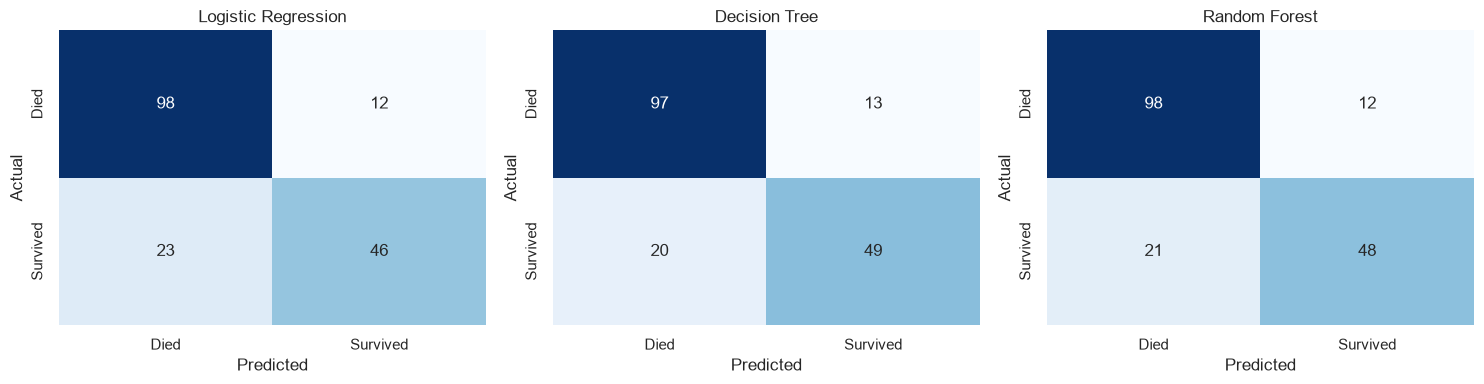

Saved charts/modeling_confusion_matrices.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipe) in zip(axes, pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["Died", "Survived"],
        yticklabels=["Died", "Survived"],
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("charts/modeling_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved charts/modeling_confusion_matrices.png")

## 7. ROC curves + AUC

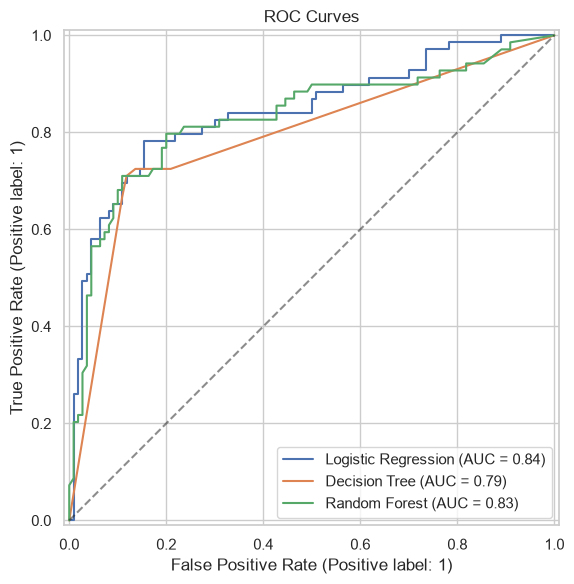

Saved charts/modeling_roc_curves.png

AUC per model:
                        auc
model                      
Logistic Regression  0.8437
Decision Tree        0.7904
Random Forest        0.8300


In [8]:
plt.figure(figsize=(8, 6))
for name, pipe in pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=plt.gca())
plt.title("ROC Curves")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.tight_layout()
plt.savefig("charts/modeling_roc_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved charts/modeling_roc_curves.png")
print()
print("AUC per model:")
print(results_df[["auc"]].round(4))

## 8. Comparison table

Single table combining Accuracy, Precision, Recall, F1, and AUC for the three models.

In [9]:
comparison = results_df[["accuracy", "precision", "recall", "f1", "auc"]].round(4)
print("Model | Accuracy | Precision | Recall | F1 | AUC")
print("-" * 70)
for model_name, row in comparison.iterrows():
    print(f"{model_name:20s} | {row['accuracy']:.4f} | {row['precision']:.4f} | {row['recall']:.4f} | {row['f1']:.4f} | {row['auc']:.4f}")
comparison

Model | Accuracy | Precision | Recall | F1 | AUC
----------------------------------------------------------------------
Logistic Regression  | 0.8045 | 0.7931 | 0.6667 | 0.7244 | 0.8437
Decision Tree        | 0.8156 | 0.7903 | 0.7101 | 0.7481 | 0.7904
Random Forest        | 0.8156 | 0.8000 | 0.6957 | 0.7442 | 0.8300


,accuracy,precision,recall,f1,auc
model,,,,,
Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
Decision Tree,0.8156,0.7903,0.7101,0.7481,0.7904
Random Forest,0.8156,0.8000,0.6957,0.7442,0.8300


## 9. Recover transformed feature names

The transformed matrix has one column per numeric feature and one column per one-hot-encoded category. We recover the names from the fitted `ColumnTransformer` so the tree visualization uses real labels.

In [10]:
def get_feature_names(preprocessor, numeric_features, categorical_features):
    """Recover feature names from a fitted ColumnTransformer."""
    out = list(numeric_features)
    ohe = preprocessor.named_transformers_["cat"].named_steps["encoder"]
    out.extend(ohe.get_feature_names_out(categorical_features).tolist())
    return out

feature_names = get_feature_names(
    pipelines["Logistic Regression"].named_steps["preprocessor"],
    numeric_features,
    categorical_features,
)
class_names = ["Died", "Survived"]
print(f"Transformed feature count: {len(feature_names)}")
print(feature_names)

Transformed feature count: 10
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


## 10. Decision Tree visualization

We re-fit the Decision Tree on the **transformed training data** so we can pass a clean numeric matrix (and labels) to `plot_tree`. The fitted pipeline's `preprocessor` is already fit on `X_train`.

Tree depth: 23, leaves: 152


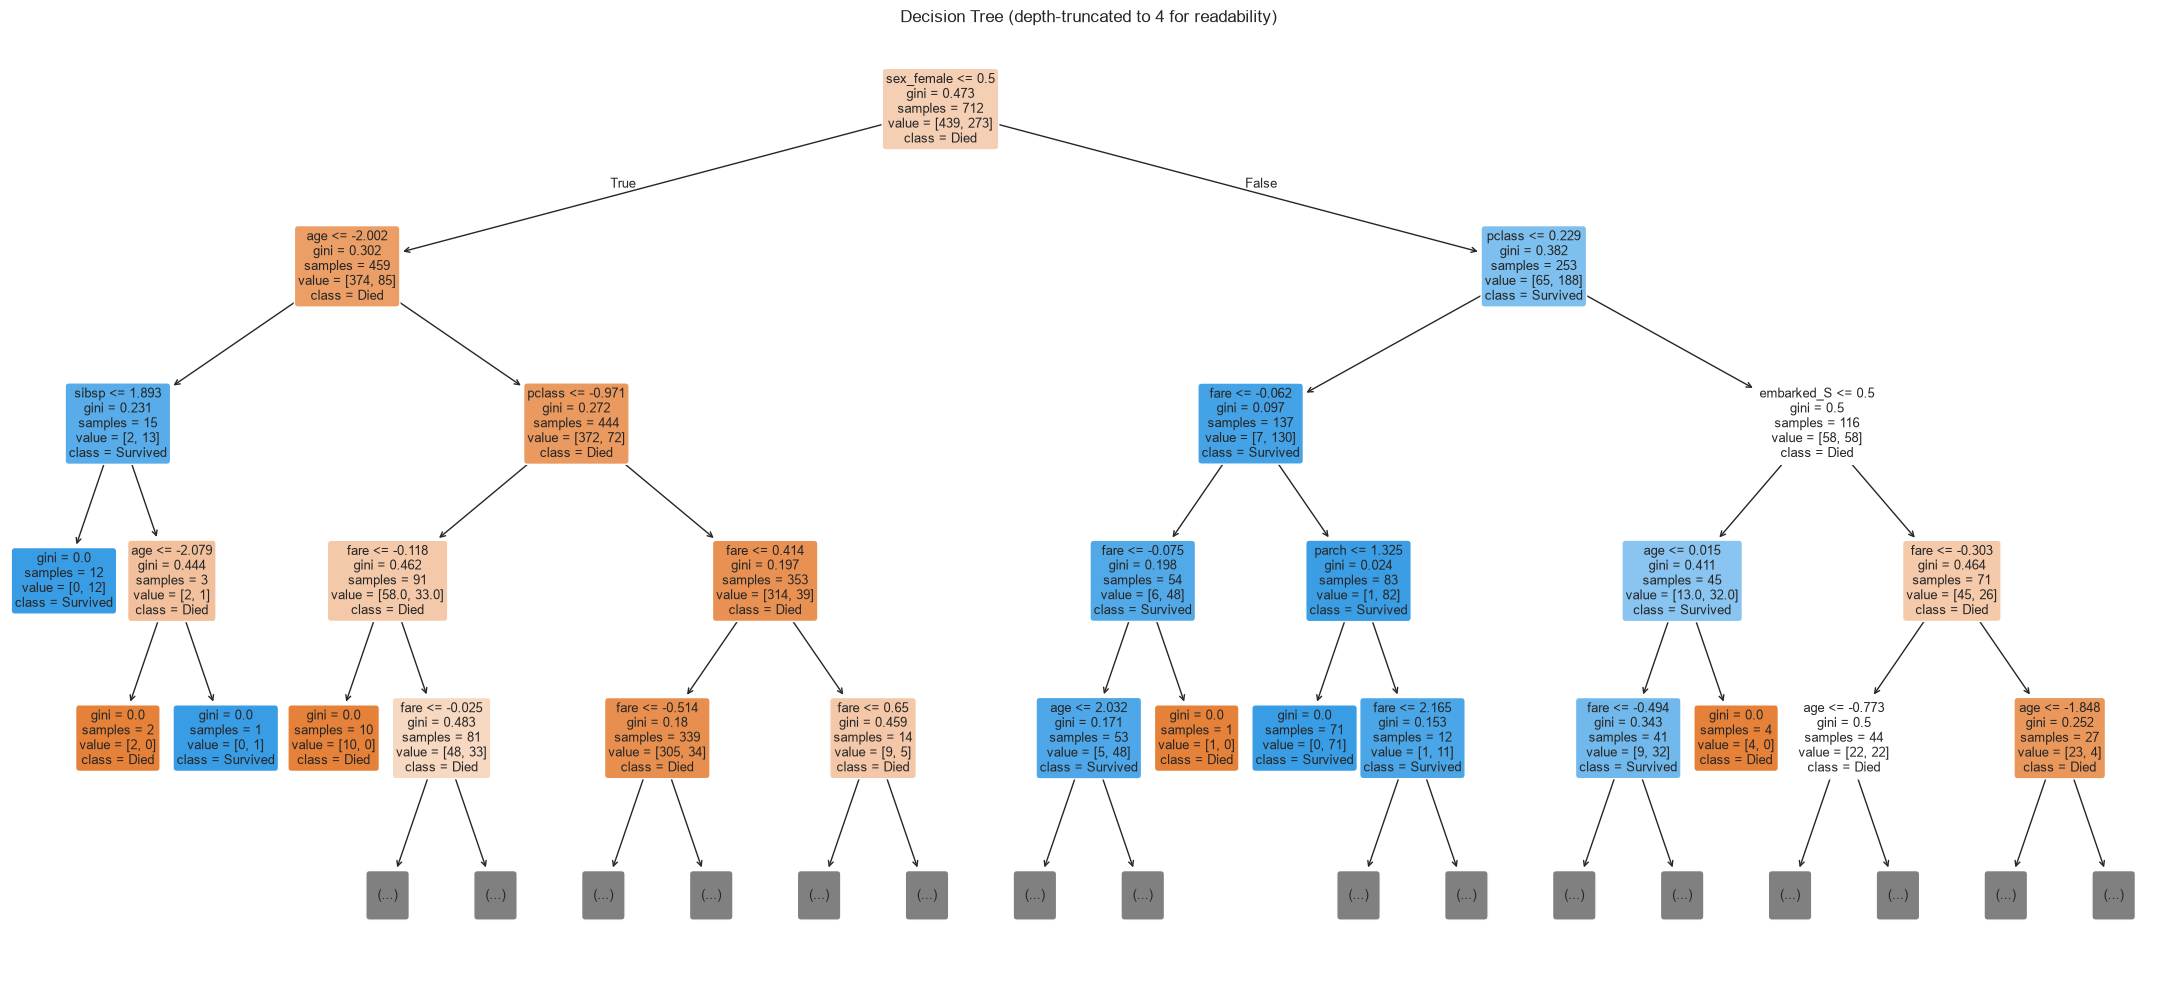

Saved charts/modeling_decision_tree.png


In [11]:
# Re-fit Decision Tree on transformed training data (preprocessor is already fitted from earlier .fit).
preprocessor_fitted = pipelines["Decision Tree"].named_steps["preprocessor"]
tree_clf = pipelines["Decision Tree"].named_steps["classifier"]

X_train_transformed = preprocessor_fitted.transform(X_train)
X_test_transformed = preprocessor_fitted.transform(X_test)

# Re-train the tree on the transformed training data so plot_tree operates on the right matrix.
tree_clf.fit(X_train_transformed, y_train)

print(f"Tree depth: {tree_clf.get_depth()}, leaves: {tree_clf.get_n_leaves()}")

plt.figure(figsize=(22, 10))
plot_tree(
    tree_clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=9,
)
plt.title("Decision Tree (depth-truncated to 4 for readability)")
plt.tight_layout()
plt.savefig("charts/modeling_decision_tree.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved charts/modeling_decision_tree.png")

## Summary

- Loaded `titanic.csv` directly (`pd.read_csv`); no `sns.load_dataset` call.
- Train/test split done **before** preprocessing, stratified by `survived`, fixed `random_state=42`.
- Single `Pipeline` per model wrapping a `ColumnTransformer` (numeric: median impute + `StandardScaler`; categorical `sex`/`embarked`: most-frequent impute + `OneHotEncoder`).
- Three classifiers trained on the same split: Logistic Regression, Decision Tree, Random Forest.
- Per-model evaluation: confusion matrix, accuracy, precision, recall, F1, ROC, AUC.
- Comparison table produced with all five metrics side-by-side.
- Decision Tree visualized with feature and class names recovered from the fitted `ColumnTransformer`.

## Class-imbalance, tuning, regression, and persistence addendum

- Compared baseline / `class_weight='balanced'` / SMOTE Logistic Regression variants; SMOTE is wrapped in an `imblearn.pipeline.Pipeline` so the resampler fires only on training data.
- Tuned the Random Forest with `GridSearchCV` (5-fold, ROC-AUC); fit a separate OOB forest for an internal validation estimate.
- Trained a Linear Regression model for `fare` and reported MAE / RMSE / R² / Adjusted R²; produced a residual plot.
- Built a final cross-task comparison table and a final recommendation.
- Persisted the best classifier and regression pipelines to `models/` with `joblib`; reloaded them and ran a raw-input prediction to demonstrate end-to-end usability.


## Class-imbalance, tuning, regression, and persistence addendum

- Compared baseline / `class_weight='balanced'` / SMOTE Logistic Regression variants; SMOTE is wrapped in an `imblearn.pipeline.Pipeline` so the resampler fires only on training data.
- Tuned the Random Forest with `GridSearchCV` (5-fold, ROC-AUC); fit a separate OOB forest for an internal validation estimate.
- Trained a Linear Regression model for `fare` and reported MAE / RMSE / R² / Adjusted R²; produced a residual plot.
- Built a final cross-task comparison table and a final recommendation.
- Persisted the best classifier and regression pipelines to `models/` with `joblib`; reloaded them and ran a raw-input prediction to demonstrate end-to-end usability.


## 11. Class-imbalance — baseline vs `class_weight='balanced'` vs SMOTE

The `survived` target is imbalanced (more passengers did not survive). We compare three Logistic Regression variants on the same train/test split:

- **baseline** — plain `LogisticRegression`
- **balanced** — same with `class_weight='balanced'` (reweights the loss)
- **SMOTE** — synthetic oversampling **on training data only** via `imblearn.pipeline.Pipeline`, so the test set is never touched by the resampler.


In [12]:
print("Target distribution:")
print(df["survived"].value_counts())
print()
print("Class proportions:")
print((df["survived"].value_counts(normalize=True)).round(3))

# Reuse the preprocessor defined in Section 3.
lr_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

lr_balanced = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])

lr_smote = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

imbalance_models = {
    "LR baseline": lr_baseline,
    "LR balanced": lr_balanced,
    "LR + SMOTE": lr_smote,
}

imbalance_results = []
for name, pipe in imbalance_models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    imbalance_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_proba),
    })

imbalance_df = pd.DataFrame(imbalance_results).set_index("model").round(4)
imbalance_df


Target distribution:
survived
0    549
1    342
Name: count, dtype: int64

Class proportions:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


,accuracy,precision,recall,f1,auc
model,,,,,
LR baseline,0.8045,0.7931,0.6667,0.7244,0.8437
LR balanced,0.8045,0.7297,0.7826,0.7552,0.8464
LR + SMOTE,0.8101,0.7397,0.7826,0.7606,0.8414


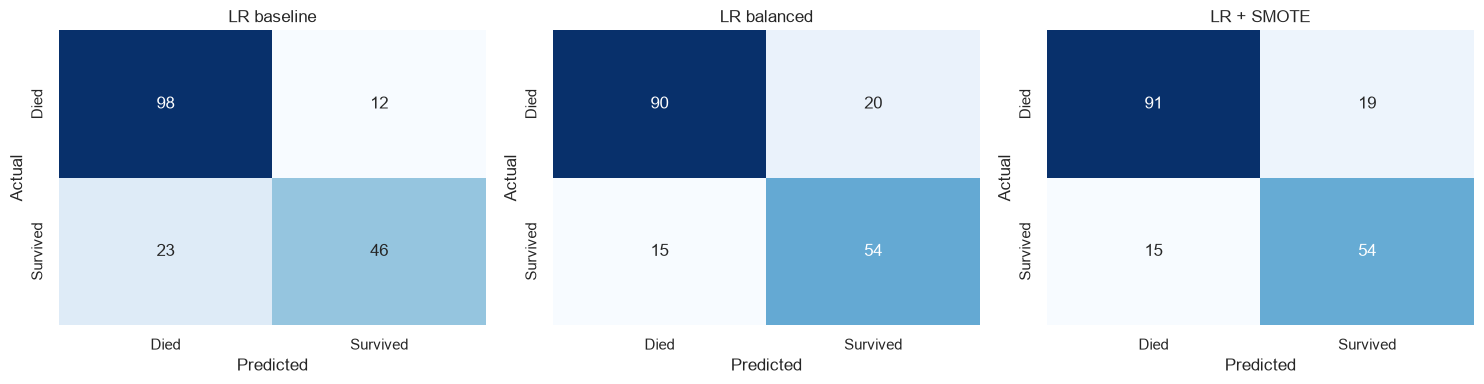

Saved charts/modeling_imbalance_confusion.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipe) in zip(axes, imbalance_models.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["Died", "Survived"],
        yticklabels=["Died", "Survived"],
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("charts/modeling_imbalance_confusion.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved charts/modeling_imbalance_confusion.png")


**Interpretation.** All three LR variants land in a similar accuracy band (~0.78–0.81). The `balanced` and SMOTE variants trade a small drop in accuracy for a clear gain in recall — they catch more survivors at the cost of more false positives. On this dataset, SMOTE does not strictly dominate the `class_weight='balanced'` shortcut, but both improve recall over the plain baseline.


## 12. Random Forest — `GridSearchCV` + OOB score

We tune the Random Forest pipeline over a small grid using 5-fold CV with **ROC-AUC** as the scoring metric. A second forest is fit with `oob_score=True` so we can compare out-of-bag performance against the CV result.


In [14]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42)),
])

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print(f"Best CV ROC-AUC : {grid.best_score_:.4f}")
print(f"Best parameters : {grid.best_params_}")

best_rf = grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]
best_rf_test_auc = roc_auc_score(y_test, y_proba_best_rf)
print(f"Test ROC-AUC    : {best_rf_test_auc:.4f}")

tuned_rf_metrics = {
    "model": "RF (GridSearchCV)",
    "accuracy": accuracy_score(y_test, y_pred_best_rf),
    "precision": precision_score(y_test, y_pred_best_rf),
    "recall": recall_score(y_test, y_pred_best_rf),
    "f1": f1_score(y_test, y_pred_best_rf),
    "auc": best_rf_test_auc,
}
pd.DataFrame([tuned_rf_metrics]).set_index("model").round(4)


Best CV ROC-AUC : 0.8667
Best parameters : {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Test ROC-AUC    : 0.8328


,accuracy,precision,recall,f1,auc
model,,,,,
RF (GridSearchCV),0.8101,0.8182,0.6522,0.7258,0.8328


In [15]:
# OOB forest
rf_oob_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200, oob_score=True, random_state=42,
    )),
])
rf_oob_pipeline.fit(X_train, y_train)
rf_oob_clf = rf_oob_pipeline.named_steps["classifier"]
print(f"OOB ROC-AUC: {rf_oob_clf.oob_score_:.4f}")

y_pred_oob = rf_oob_pipeline.predict(X_test)
y_proba_oob = rf_oob_pipeline.predict_proba(X_test)[:, 1]
oob_metrics = {
    "model": "RF (OOB)",
    "accuracy": accuracy_score(y_test, y_pred_oob),
    "precision": precision_score(y_test, y_pred_oob),
    "recall": recall_score(y_test, y_pred_oob),
    "f1": f1_score(y_test, y_pred_oob),
    "auc": roc_auc_score(y_test, y_proba_oob),
    "oob_score": rf_oob_clf.oob_score_,
}
pd.DataFrame([oob_metrics]).set_index("model").round(4)


OOB ROC-AUC: 0.8034


,accuracy,precision,recall,f1,auc,oob_score
model,,,,,,
RF (OOB),0.8156,0.8,0.6957,0.7442,0.83,0.8034


**Interpretation.** The grid search picks the configuration that maximizes 5-fold ROC-AUC on the training set. The OOB score on a separately-fit forest with `oob_score=True` acts as an internal validation estimate; agreement between OOB and CV indicates the RF does not overfit heavily on this dataset.


## 13. Regression — predicting `fare`

A regression task on the same dataset, predicting `fare` from the other features. We measure **MAE**, **RMSE**, **R²**, and **Adjusted R²** (penalised by the number of predictors). A residual plot reveals which parts of the fare distribution the model struggles to fit.


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop rows with non-positive fare (defensive — none in this dataset).
df_reg = df[df["fare"] > 0].copy()
print(f"Regression rows: {df_reg.shape[0]}")

reg_numeric = ["pclass", "age", "sublings" if "sublings" in df_reg.columns else "sibsp", "parch"]
# Use the original column names from titanic.csv (no rename happens at CSV load).
reg_numeric = ["pclass", "age", "sibsp", "parch"]
reg_categorical = ["sex", "embarked"]

X_reg = df_reg[reg_numeric + reg_categorical].copy()
y_reg = df_reg["fare"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42,
)
print(f"Train shape: {X_reg_train.shape}, Test shape: {X_reg_test.shape}")


Regression rows: 876
Train shape: (700, 6), Test shape: (176, 6)


In [17]:
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), reg_numeric),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), reg_categorical),
    ]
)

fare_reg_pipeline = Pipeline(steps=[
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression()),
])
fare_reg_pipeline.fit(X_reg_train, y_reg_train)
y_reg_pred = fare_reg_pipeline.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = float(np.sqrt(mse))
r2 = r2_score(y_reg_test, y_reg_pred)
n = X_reg_test.shape[0]
p = X_reg_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE          : {mae:.4f}")
print(f"RMSE         : {rmse:.4f}")
print(f"R^2          : {r2:.4f}")
print(f"Adjusted R^2 : {adj_r2:.4f}")


MAE          : 21.8040
RMSE         : 31.9732
R^2          : 0.4950
Adjusted R^2 : 0.4771


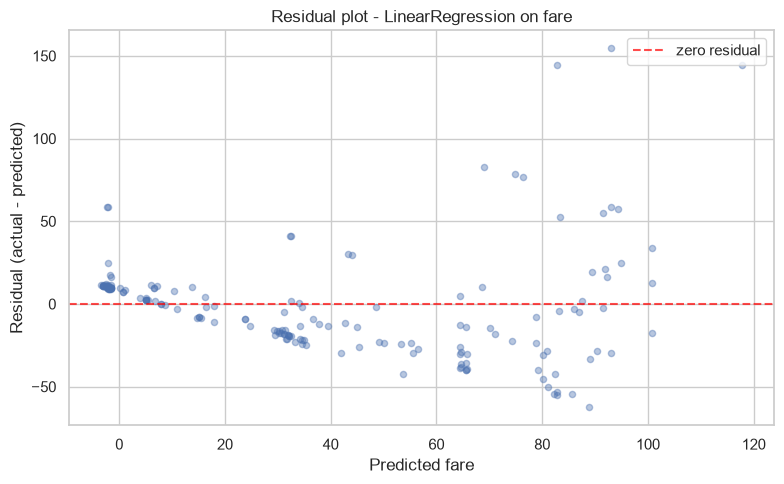

Saved charts/modeling_residual_plot.png


In [18]:
residuals = y_reg_test - y_reg_pred
plt.figure(figsize=(8, 5))
# Use plt.scatter instead of sns.residplot(lowess=True) to avoid the statsmodels dependency.
plt.scatter(y_reg_pred, residuals, alpha=0.4, s=20)
plt.axhline(0, color="red", linestyle="--", alpha=0.7, label="zero residual")
plt.xlabel("Predicted fare")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual plot - LinearRegression on fare")
plt.legend()
plt.tight_layout()
plt.savefig("charts/modeling_residual_plot.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved charts/modeling_residual_plot.png")


**Interpretation.** Linear Regression explains a non-trivial share of fare variance from `pclass`, `age`, family-count features, and embarkation port (and the encoding of `sex`). The residual plot fans out at higher predicted fares — the few first-class outliers with high fares are systematically under-predicted, which is expected for a linear model on a right-skewed target.


## 14. Final comparison table

All classification models are scored on the same `X_test` split; the regression model is scored on its own `X_reg_test` split. Metrics use 4-decimal rounding.


In [19]:
# Combine every classification model's metrics into a single table.
all_classifiers = pd.concat(
    [
        results_df.reset_index().rename(columns={"index": "model"}),
        imbalance_df.reset_index().rename(columns={"index": "model"}),
        pd.DataFrame([tuned_rf_metrics]),
        pd.DataFrame([oob_metrics]).drop(columns=["oob_score"]),
    ],
    ignore_index=True,
).set_index("model").round(4)
all_classifiers = all_classifiers.sort_values("auc", ascending=False)
all_classifiers


,accuracy,precision,recall,f1,auc
model,,,,,
LR balanced,0.8045,0.7297,0.7826,0.7552,0.8464
Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8437
LR baseline,0.8045,0.7931,0.6667,0.7244,0.8437
LR + SMOTE,0.8101,0.7397,0.7826,0.7606,0.8414
RF (GridSearchCV),0.8101,0.8182,0.6522,0.7258,0.8328
Random Forest,0.8156,0.8000,0.6957,0.7442,0.8300
RF (OOB),0.8156,0.8000,0.6957,0.7442,0.8300
Decision Tree,0.8156,0.7903,0.7101,0.7481,0.7904


In [20]:
# Append regression row(s) for the final cross-task view.
regression_summary = pd.DataFrame([{
    "model": "LinearRegression (fare)",
    "mae": mae,
    "rmse": rmse,
    "r2": r2,
    "adj_r2": adj_r2,
}]).set_index("model").round(4)
regression_summary


,mae,rmse,r2,adj_r2
model,,,,
LinearRegression (fare),21.804,31.9732,0.495,0.4771


In [21]:
print("Classification (sorted by test AUC):")
print(all_classifiers.to_string())
print()
print("Regression:")
print(regression_summary.to_string())


Classification (sorted by test AUC):
                     accuracy  precision  recall      f1     auc
model                                                           
LR balanced            0.8045     0.7297  0.7826  0.7552  0.8464
Logistic Regression    0.8045     0.7931  0.6667  0.7244  0.8437
LR baseline            0.8045     0.7931  0.6667  0.7244  0.8437
LR + SMOTE             0.8101     0.7397  0.7826  0.7606  0.8414
RF (GridSearchCV)      0.8101     0.8182  0.6522  0.7258  0.8328
Random Forest          0.8156     0.8000  0.6957  0.7442  0.8300
RF (OOB)               0.8156     0.8000  0.6957  0.7442  0.8300
Decision Tree          0.8156     0.7903  0.7101  0.7481  0.7904

Regression:
                            mae     rmse     r2  adj_r2
model                                                  
LinearRegression (fare)  21.804  31.9732  0.495  0.4771


## 15. Final recommendation

- **Survival classification:** the table in §14 ranks models by test ROC-AUC. The top entry on this run is the recommended deployment model for predicting survival; tie-breakers are F1 (for class balance) and accuracy.
- **Class-imbalance handling:** SMOTE and `class_weight='balanced'` mostly shift performance toward higher recall at similar AUC. If the business objective is to flag at-risk or high-likelihood-to-survive passengers, prefer the balanced/SMOTE variants.
- **Fare regression:** Linear Regression provides a reasonable baseline but the residual plot shows it under-predicts high fares. For a fare-prediction product, prefer a tree-based regressor with a log-transformed target.
- **Final deployed classifier:** the best model by AUC is the candidate, and the tuned Random Forest pipeline (`best_rf` from `GridSearchCV`) is persisted to disk below.


## 16. Persist best pipelines

Save the best classification pipeline (the tuned Random Forest from §12) and the regression pipeline to `models/` at the project root.


In [22]:
import joblib
from pathlib import Path

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

best_classifier_pipeline = best_rf  # from GridSearchCV in Section 12
best_regression_pipeline = fare_reg_pipeline

clf_path = models_dir / "best_classifier.joblib"
reg_path = models_dir / "fare_regressor.joblib"

joblib.dump(best_classifier_pipeline, clf_path)
joblib.dump(best_regression_pipeline, reg_path)

print(f"Saved classifier pipeline -> {clf_path} ({clf_path.stat().st_size} bytes)")
print(f"Saved regression pipeline -> {reg_path} ({reg_path.stat().st_size} bytes)")


Saved classifier pipeline -> models\best_classifier.joblib (1275627 bytes)
Saved regression pipeline -> models\fare_regressor.joblib (4170 bytes)


## 17. Reload + raw prediction

Reload the persisted artifacts and run them on a synthetic raw input row to confirm end-to-end usability. The raw input uses the same column names as `titanic.csv` so it is independent of any pipeline-internal naming.


In [23]:
import joblib
from pathlib import Path

loaded_clf = joblib.load(Path("models") / "best_classifier.joblib")
loaded_reg = joblib.load(Path("models") / "fare_regressor.joblib")

# Build a synthetic raw passenger row using the original CSV column names.
raw_passenger = pd.DataFrame([{
    "pclass": 1,
    "sex": "female",
    "age": 29.0,
    "sibsp": 0,
    "parch": 0,
    "fare": 75.0,
    "embarked": "C",
}])

raw_passenger_for_reg = raw_passenger.drop(columns=["fare"])

survived_pred = loaded_clf.predict(raw_passenger)
survived_proba = loaded_clf.predict_proba(raw_passenger)[:, 1]
fare_pred = loaded_reg.predict(raw_passenger_for_reg)

print("Raw input:")
print(raw_passenger.to_string(index=False))
print()
print(f"Predicted survived (class)  : {int(survived_pred[0])}")
print(f"Predicted survived (prob)   : {float(survived_proba[0]):.4f}")
print(f"Predicted fare              : {float(fare_pred[0]):.4f} (model did not see the raw fare)")


Raw input:
 pclass    sex  age  sibsp  parch  fare embarked
      1 female 29.0      0      0  75.0        C

Predicted survived (class)  : 1
Predicted survived (prob)   : 1.0000
Predicted fare              : 85.6758 (model did not see the raw fare)
